# Reinforcement Learning ep.3: Q-Learning in continous spaces

*Goal: use Deep Q-Learning to play CartPole*

## Introduction to Cartpole

A pole is attached by an un-actuated joint to a cart, which moves along a 1-dim frictionless track. The pendulum starts upright, and the goal is to prevent it from falling over by increasing and reducing the cart's velocity.


#### Action space
Breakout has the action space `Discrete(2)` with the table below lists the meaning of each action's meanings. 

- 1: Left
- 2: Right


#### Observations
By default, the environment returns the RGB image that is displayed to human players as an observation.

#### Rewards
In this task, rewards are +1 for every incremental timestep. This means better performing scenarios will run for longer duration, accumulating larger return.

#### Episode termination
* Pole Angle is more than 12 degrees
* Cart Position is more than 2.4 (center of the cart reaches the edge of the display)
* Episode length is greater than 500, or another value set by the variable *env.\_max\_episode\_steps*

#### State space

At each game frame, the game engine provides information of the state. This state is then used to compute the features the agent will use. 

As starting state, all observations are assigned a uniformly random value in $(-0.05, 0.05)$.

The CartPole task is designed so that the inputs to the agent are 4 real values representing the environment state `(cart position, cart velocity, pole position, pole velocity)`. We take these 4 inputs without any scaling and pass them through a small fully-connected network with 2 outputs, one for each action. 


## Implementation
First, let's install the version of Gymnasium containing this environment.


In [1]:
%%capture
!pip install "gymnasium[classic_control]"

In [2]:
import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation

from IPython import display
from IPython.display import clear_output

import random
import math
from time import sleep
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

The environment is the following:

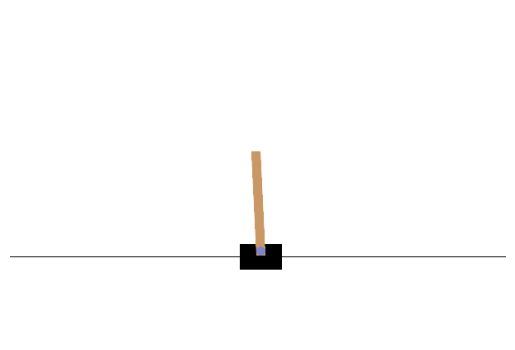

In [3]:
env = gym.make('CartPole-v1', render_mode='rgb_array').env

env.reset()
img = env.render()
plt.axis('off')
plt.imshow(img)

We can see the size of the State space and of the Action space:

In [4]:
print("Action Space: {}".format(env.action_space))
print()

print("State space: ", env.observation_space)
print()

low_bounds, high_bounds = (env.observation_space.low, env.observation_space.high)
print("1st element:\tPosition of the cart along the x-axis. Bounds: [%2.1f, %2.1f]" %(low_bounds[0], high_bounds[0]))
print("2nd element:\tCart velocity. Not bounded")
print("3rd element:\tPole angle. Bounds in radiants: [%2.1f, %2.1f]" %(low_bounds[2], high_bounds[2]))
print("4th element:\tPole velocity at its tip. Not bounded")

Action Space: Discrete(2)

State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

1st element:	Position of the cart along the x-axis. Bounds: [-4.8, 4.8]
2nd element:	Cart velocity. Not bounded
3rd element:	Pole angle. Bounds in radiants: [-0.4, 0.4]
4th element:	Pole velocity at its tip. Not bounded


## Trying a naive strategy
One can define a naive strategy (i.e. the action to take by knowing the current state) based on the physical intuition of the problem. 

Remember that the best performance is having an episode cumulative reward of 500, because after 500 steps the environment automatcally resets (see episode termination above).
Having a smaller reward means that the episode has ended before 500 steps because (1) the angle of the pole has become too large, (2) the cart is outside the boundaries.

In [5]:
def my_bad_policy(state):
    """
    If the pole angle is less than 0 (bent towards left) I apply a force towards left.
    """
    if state[2] < 0:
        return 0
    else:
        return 1 
    
def random_policy(state):
    return env.action_space.sample()

In [6]:
def run(env, n_episodes, strategy, max_iter = 1000):
    """
    Running the enviroment for a given number of episodes, according to a given strategy.
    It returns the average reward over all the episodes and the plotting frames for each episode.
    """
    done = False
    average_reward = 0   # cumulative reward averaged over all the episodes
    episodeframes = []   # list to save frames for each episode
    
    for _ in range(n_episodes): # cycle over all the episodes
        
        frames = []            # save frames
        state = env.reset()[0] # episode initialization
        ep_reward = 0          # reward for the episode
        
        it = 0
        while not done and it < max_iter: 
            it += 1
            action = strategy(state) # Getting the action from the heuristic policy
            state, reward, done, truncated, info = env.step(action)
            ep_reward += reward

            frames.append(env.render())
            
            if truncated: # Check if the state is terminal
                break
                
        average_reward += ep_reward / float(n_episodes) 
        episodeframes.append(frames)
        
    return average_reward, episodeframes

Printing the average reward of the heuristic policy over some episodes:

In [7]:
n_episodes = 5

badpolicy = run(env, n_episodes, my_bad_policy)
randompolicy = run(env, n_episodes, random_policy)

print(badpolicy[0])
print(randompolicy[0])

5.2
4.0


In [8]:
def display_animation(frames):
    # turn off matplotlib plot in notebook
    plt.ioff()

    fps = 5   # Set frames per seconds
    dpi = 300  # Set dots per inch
    interval = 100  # Interval between frames (in ms)

    # Retrieve frames from experience buffer
    allframes = []
    for frame in frames:
        allframes.append(frame)

    # Fix frame size
    plt.figure(figsize=(allframes[0].shape[1] / dpi, allframes[0].shape[0] / dpi), dpi=dpi)
    patch = plt.imshow(allframes[0])
    plt.axis('off')

    # Generate animation
    def animate(i):
        patch.set_data(allframes[i])

    anim = animation.FuncAnimation(plt.gcf(), animate, frames=len(allframes), interval=interval)

    video = anim.to_html5_video()
    html = display.HTML(video)
    return html

In [9]:
html = display_animation(badpolicy[1][0])
display.display(html)

## Q Learning

##### **1. Implement Q Learning for CartPole.**

Before training can begin two things need to be set up. This first of these are bins which will represent the environment with *discrete* values instead of *continuous* values. This will lower the number of states that need to be adjusted.  
For CartPole-v1 the cart location, cart speed, pole and pole speed are recorded in the environment. Each of these has $n$ bins and have been given a range for each bin.

The Q table also needs to be set up. This has the same shape as the bins with the addition axis for a number of actions that can be performed. For CartPole this is 2. 

In [10]:
# we need to discretize the space

n_bins = 12

q_table = np.zeros((n_bins, n_bins, n_bins, n_bins, 2))

In [11]:
def discretize_state(state, min_state = np.array([-4.8, -2, -0.41887903, -2]),
                            max_state = np.array([4.8,   2,  0.41887903,  2]), 
                            n_bins = n_bins):
    # find conversion between continuous val and bins
    bw = (max_state - min_state)/n_bins
    bin_idx = np.floor((state - min_state)/bw).astype(np.int32)

    bin_idx = np.maximum(0,bin_idx)
    bin_idx = np.minimum(n_bins - 1,bin_idx)
    return bin_idx
discretize_state(env.unwrapped.state)

array([5, 5, 5, 5], dtype=int32)

In [12]:
from tqdm import tqdm

# Hyperparameters
alpha = 0.1
gamma = 0.95
epsilon = 1.0
min_epsilon = 0.01
epsilon_decay = 0.9995
Iter = 10000
max_iter_per_episode = 1000

# For plotting metrics
all_epochs = []
all_penalties = []

for episode in tqdm(range(Iter)):
    env.reset()

    total_reward = 0
    epsilon = max(epsilon * epsilon_decay, min_epsilon)
    state = env.unwrapped.state 

    for it in range(max_iter_per_episode):

        d_state = discretize_state(state)

        prob = np.random.rand()

        max_q_action = np.argmax(q_table[tuple(d_state)])
        if prob > epsilon:
            action = max_q_action
        else:
            while True:
                action = np.random.randint(env.action_space.n)
                if action != max_q_action:
                    break
        
        state_prime, reward, done, truncated, info = env.step(action)
        d_state_prime = discretize_state(state_prime)

        # update q
        
        total_reward += reward

        q_table[tuple(d_state) + (action,)] = ((1 - alpha)*q_table[tuple(d_state) + (action,)] +  
        alpha*(reward + gamma*np.max(q_table[tuple(d_state_prime)]) ) )

        state = state_prime

        
        if done:
            break
    
    all_penalties.append(total_reward)






        
print("Training finished.\n")

100%|██████████| 10000/10000 [01:24<00:00, 118.60it/s]

Training finished.



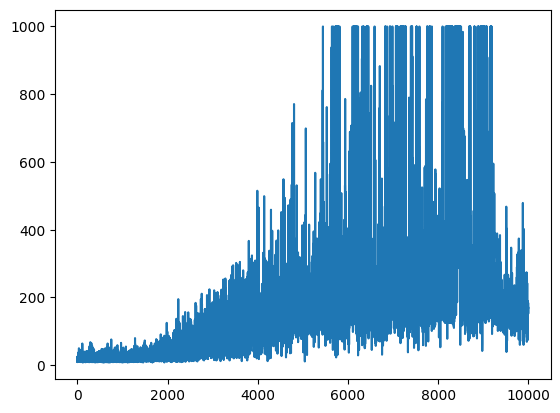

In [13]:
plt.close()
plt.figure()
plt.plot(all_penalties)
plt.show()

In [14]:
def q_table_policy(state, q_table = q_table):
    d_state = discretize_state(state)
    action = np.argmax(q_table[d_state[0], d_state[1], d_state[2], d_state[3], :])
    return action

qt = run(env, 5, q_table_policy)
print(qt[0])

19.0


In [15]:
display_animation(qt[1][0])

In discrete Q-Learning, you have a table $Q(s, a)$. In Linear Approximation, we define $Q$ as a weighted sum of the state features:
$$Q(s, a) \approx \sum_{i} w_{a,i} \cdot \phi_i(s)$$
Where:
* $\phi_i(s)$ are the features of the environment (position, angle, etc.).
* $w_{a,i}$ are the weights for action $a$ that we need to "learn."



### 2. The Reconstruction Logic
To build this from scratch, you follow four logical steps:

#### A. Feature Engineering (The "Input")
The raw values from CartPole have different scales (e.g., angle is small, velocity can be large). To make the math stable, we **normalize** them and add a **bias** (a constant 1.0) so the model can have an "intercept."
* *Why?* Without a bias, if all inputs are 0, the output is forced to be 0. The bias allows the agent to learn a baseline value for "just staying alive."

#### B. The Prediction (The "Forward Pass")
We maintain a weight matrix of shape `(num_actions, num_features)`. To get the Q-values, we perform a dot product. This gives us one score for "Left" and one for "Right" simultaneously.
```python
q_values = np.dot(weights, features)
```

#### C. The Objective (The "Target")
We use the **Bellman Equation** to decide what the value *should* have been. If we took an action and survived, the new target is the immediate reward plus the discounted value of the next state:
$$\text{Target} = R + \gamma \max_{a'} Q(s', a')$$

#### D. The Update (The "Correction")
We calculate the **Error** (Difference between Target and our current Prediction). We then nudge the weights in the direction that reduces this error using the gradient:
$$\Delta w = \alpha \cdot (\text{Target} - \text{Prediction}) \cdot \text{Features}$$



In [79]:
n_actions = 2
n_features = 7 
weights = np.random.uniform(-0.01, 0.01, (n_actions, n_features)) 
scaler = np.array([2.4, 3.0, 0.21, 3.0]) 

def get_features(state):
    norm_s = state/ scaler
    return np.array([
        norm_s[0], norm_s[1], norm_s[2], norm_s[3], 
        norm_s[2] * norm_s[3], # Interaction: angle * speed
        norm_s[0] * norm_s[1], # Interaction: position * speed
        1.0                    # Bias term
    ])

def get_q_values(features, weights):
    return np.dot(weights, features)

alpha = 1e-3 
alpha_decay = 0.9995
min_alpha = 1e-4
gamma = 0.99
epsilon = 1.0  
epsilon_decay = 0.9995
min_epsilon = 0.01
max_episodes = 10000
max_steps_per_episode = 500 # Limit steps per episode

all_penalties = []

early_stop = 0

for episode in tqdm(range(max_episodes)):
    state, _ = env.reset()
    total_reward = 0
    
    for step in range(max_steps_per_episode):
        features = get_features(state)
        q_values = get_q_values(features, weights)
        
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_values)
            
        next_state, reward, done, truncated, _ = env.step(action)
        next_features = get_features(next_state)

        if done:
            target = reward
        else:
            next_q_values = get_q_values(next_features, weights)
            target = reward + gamma * np.max(next_q_values)

        prediction = q_values[action]
        
        weights[action] += alpha * (target - prediction) * features

        state = next_state
        total_reward += reward
        
        if done or truncated:
            break
    if step == max_steps_per_episode - 1:
        early_stop += 1
    if early_stop > 20:
        break
            
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    #alpha = max(min_alpha, alpha * alpha_decay)
    all_penalties.append(total_reward)

 72%|███████▏  | 7168/10000 [00:07<00:02, 966.45it/s] 


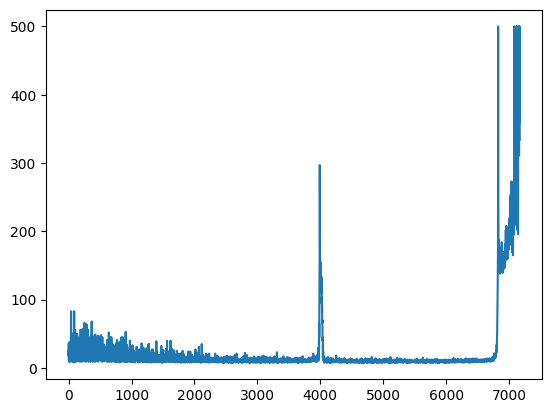

In [80]:
plt.close()
plt.figure()
plt.plot(all_penalties)
plt.show()

In [81]:
def linear_policy(state):
    features = get_features(state)
    q_values = get_q_values(features, weights)
    action = np.argmax(q_values)
    return action

linear = run(env, 5, linear_policy)
print(linear[0])

148.0


In [82]:
display_animation(linear[1][0])